# Webinar 3 — Pipeline Temporal con Boosting y Bagging
**Dataset:** PJM Hourly Energy Consumption

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [2]:
df = pd.read_csv("AEP_hourly.csv", index_col=0, parse_dates=True)
df = df.sort_index()

## 0. ¿Estacionalidad?

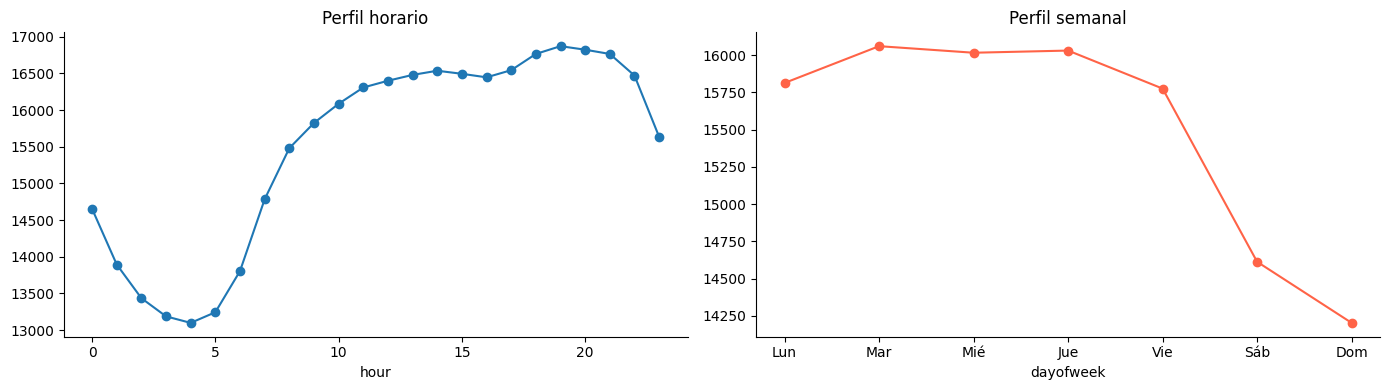

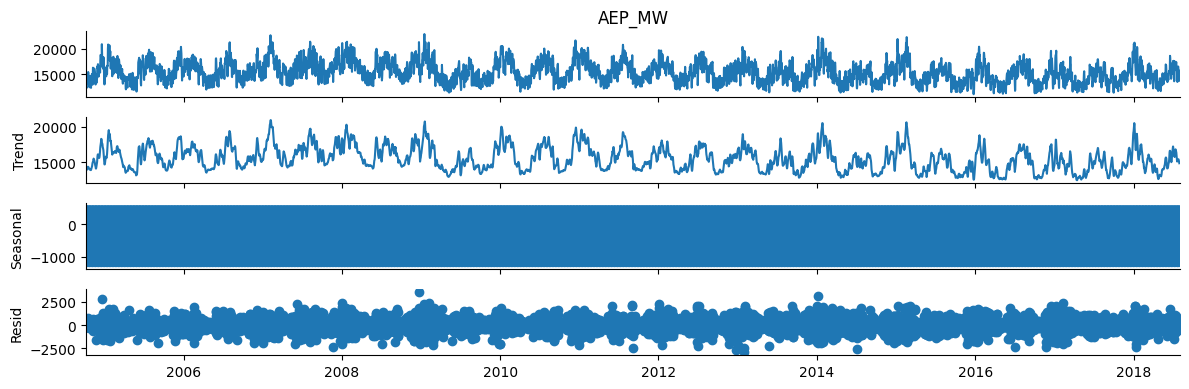

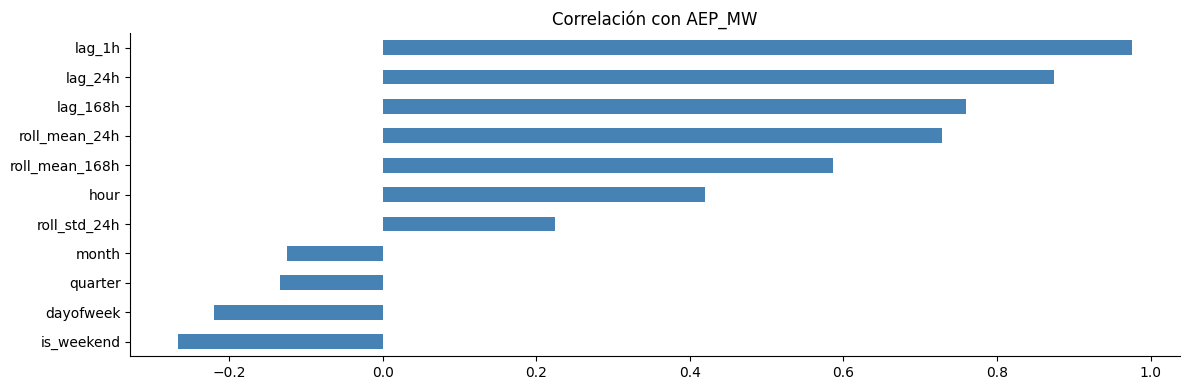

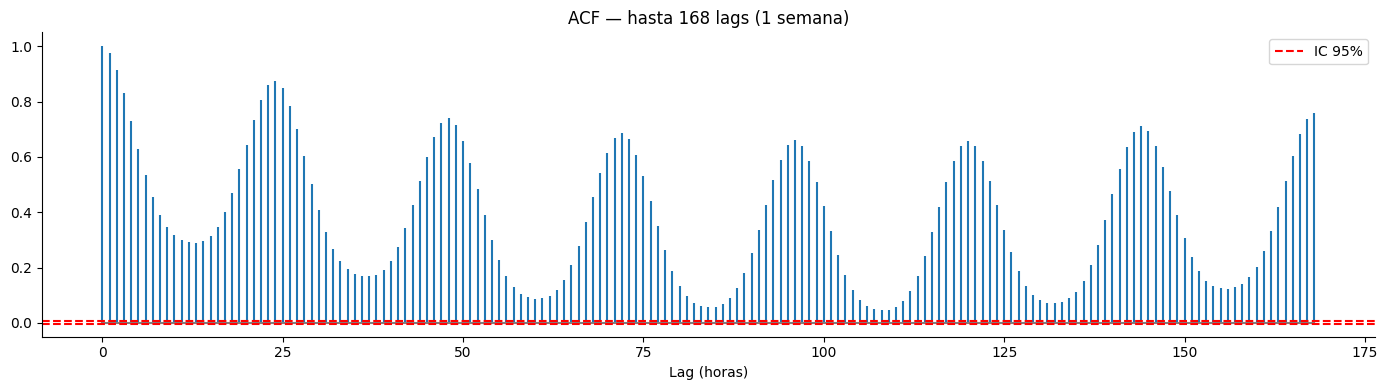

In [14]:
# Perfil horario y semanal
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df.groupby("hour")["AEP_MW"].mean().plot(ax=axes[0], marker="o", title="Perfil horario")
df.groupby("dayofweek")["AEP_MW"].mean().plot(ax=axes[1], marker="o", color="tomato", title="Perfil semanal")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(["Lun","Mar","Mié","Jue","Vie","Sáb","Dom"])
plt.tight_layout(); plt.show()

# Descomposición estacional (diaria, periodo semanal)
result = seasonal_decompose(df["AEP_MW"].resample("D").mean().dropna(), model="additive", period=7)
result.plot(); plt.tight_layout(); plt.show()

# Correlación de features con el target
df[FEATURES + ["AEP_MW"]].corr()["AEP_MW"].drop("AEP_MW").sort_values().plot(
    kind="barh", title="Correlación con AEP_MW", color="steelblue"
)
plt.tight_layout(); plt.show()


#Autocorrelación
acf_vals = acf(df["AEP_MW"].dropna(), nlags=168, fft=True)

plt.figure(figsize=(14, 4))
plt.stem(acf_vals, markerfmt=" ", basefmt="gray")
plt.axhline(1.96/np.sqrt(len(df)), color="red", linestyle="--", label="IC 95%")
plt.axhline(-1.96/np.sqrt(len(df)), color="red", linestyle="--")
plt.title("ACF — hasta 168 lags (1 semana)")
plt.xlabel("Lag (horas)")
plt.legend()
plt.tight_layout()
plt.show()

## 1. Ingeniería de características

In [3]:
def build_features(df):
    df = df.copy()
    df["hour"]       = df.index.hour
    df["dayofweek"]  = df.index.dayofweek
    df["month"]      = df.index.month
    df["quarter"]    = df.index.quarter
    df["is_weekend"] = (df.index.dayofweek >= 5).astype(int)
    df["lag_1h"]     = df["AEP_MW"].shift(1)
    df["lag_24h"]    = df["AEP_MW"].shift(24)
    df["lag_168h"]   = df["AEP_MW"].shift(168)
    shifted = df["AEP_MW"].shift(1)
    df["roll_mean_24h"]  = shifted.rolling(24).mean()
    df["roll_std_24h"]   = shifted.rolling(24).std()
    df["roll_mean_168h"] = shifted.rolling(168).mean()
    return df.dropna()

df = build_features(df)
df.head()

,AEP_MW,hour,dayofweek,month,quarter,is_weekend,lag_1h,lag_24h,lag_168h,roll_mean_24h,roll_std_24h,roll_mean_168h
Datetime,,,,,,,,,,,,
2004-10-08 01:00:00,12468.0,1,4,10,4,0,13271.0,12484.0,12379.0,14450.333333,1475.548466,13870.315476
2004-10-08 02:00:00,12046.0,2,4,10,4,0,12468.0,12054.0,11935.0,14449.666667,1476.478821,13870.845238
2004-10-08 03:00:00,11749.0,3,4,10,4,0,12046.0,11745.0,11692.0,14449.333333,1477.043983,13871.505952
2004-10-08 04:00:00,11784.0,4,4,10,4,0,11749.0,11757.0,11597.0,14449.500000,1476.725755,13871.845238
2004-10-08 05:00:00,11919.0,5,4,10,4,0,11784.0,12041.0,11681.0,14450.625000,1474.594117,13872.958333


## 2. Split temporal

Text(0.5, 1.0, 'Train / Test split')

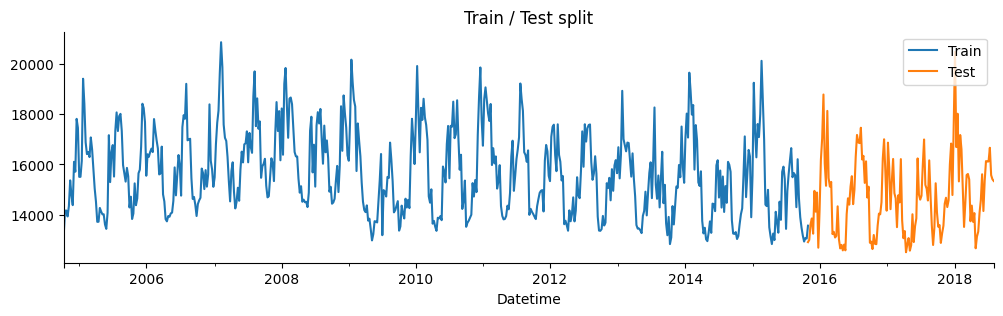

In [4]:
FEATURES = ["hour","dayofweek","month","quarter","is_weekend",
            "lag_1h","lag_24h","lag_168h",
            "roll_mean_24h","roll_std_24h","roll_mean_168h"]
TARGET = "AEP_MW"

train, test = train_test_split(df, test_size=0.2, shuffle=False)

fig, ax = plt.subplots(figsize=(12, 3))
train[TARGET].resample("W").mean().plot(ax=ax, label="Train")
test[TARGET].resample("W").mean().plot(ax=ax, label="Test")
ax.legend()
ax.set_title("Train / Test split")

## 3. Entrenar y comparar modelos

In [5]:
models = {
    "XGBoost":  XGBRegressor(n_estimators=500, learning_rate=0.05, n_jobs=-1, verbosity=0),
    "LightGBM": LGBMRegressor(n_estimators=500, learning_rate=0.05, n_jobs=-1, verbose=-1),
    "RandomForest": RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
}

results = {}
predictions = {}
for name, model in models.items():
    model.fit(train[FEATURES], train[TARGET])
    preds = model.predict(test[FEATURES])
    predictions[name] = preds
    results[name] = round(mean_absolute_error(test[TARGET], preds), 1)

pd.Series(results).sort_values()

XGBoost         131.0
LightGBM        134.5
RandomForest    140.5
dtype: float64

## 4. Importancia de features (XGBoost)

<Axes: title={'center': 'Importancia de features — XGBoost'}>

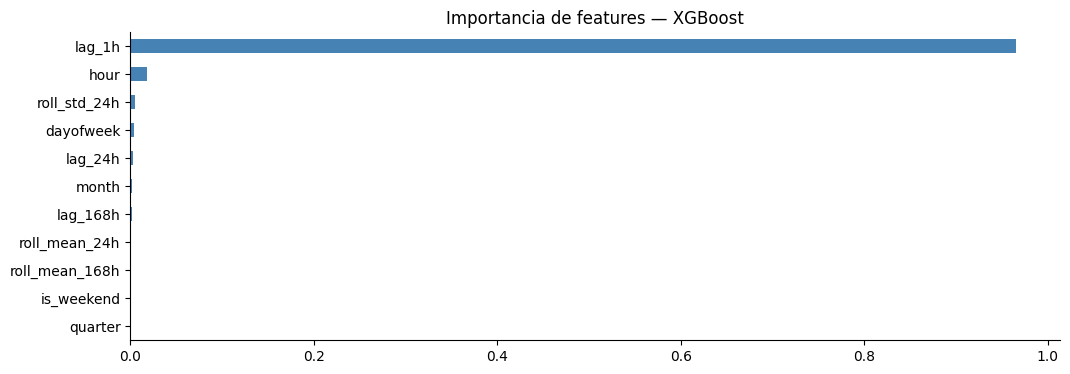

In [6]:
feat_imp = pd.Series(models["XGBoost"].feature_importances_, index=FEATURES).sort_values()
feat_imp.plot(kind="barh", title="Importancia de features — XGBoost", color="steelblue")

## 5. Visualizar predicciones vs real

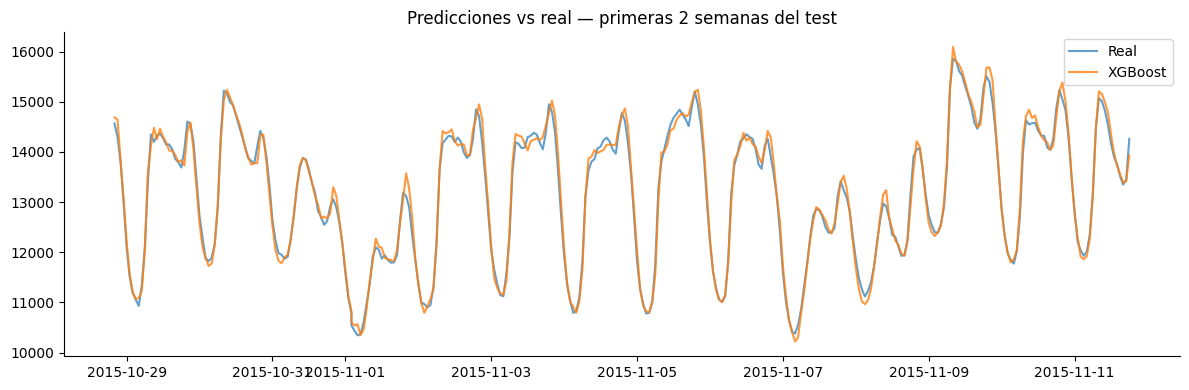

In [7]:
sample = test.iloc[:24*14]  # 2 semanas

plt.figure(figsize=(12, 4))
plt.plot(sample.index, sample[TARGET], label="Real", alpha=0.7)
plt.plot(sample.index, models["XGBoost"].predict(sample[FEATURES]),
         label="XGBoost", alpha=0.8)
plt.legend()
plt.title("Predicciones vs real — primeras 2 semanas del test")
plt.tight_layout()